# Fast GPU-Optimized Caplet Calibration

Hull-White-Heston model for Russian Key Rate caplets. 15 parameters calibrated via SPSA on a vega-weighted loss.

### Implementation
1. **Daily timesteps**: 3651 steps (daily) for accurate average rate caplet pricing
2. **Vectorized CIR**: Pre-generate all random numbers, Euler-Maruyama scheme
3. **Batch caplet pricing**: Price all caplets in parallel instead of loop
4. **SPSA optimizer**: 2 MC evals per iteration (gradient-free), antithetic variates, CRN
5. **Parameter reduction**: 6 Î¸(t) nodes + v0 + Îº + Îµ + Î» + Î³ + Î¾ + Ï(t) via PCHIP spline interpolation

### Calibration Version History

| Version | Key Changes | Result |
|---------|-------------|--------|
| **v1â€“v3** | Basic normalized RMSE loss, 4 Î¸ nodes, fixed Îº=3.0, scalar Ï=0 | Poor fit â€” long-dated caplets dominate loss, short end ignored |
| **v4** | Vega-weighted loss: $(PV_{model} - PV_{mkt}) / \nu_i$ equalizes vol contribution across maturities | Balanced fit across term structure |
| **v5** | Moneyness filter (exclude deep ITM: $K < F_{avg} - 3\%$), $\xi_{max}=0.01$ to force variance through stoch-vol channel, $\theta_{min}=0.0002$, $\epsilon_{min}=0.05$ | Eliminated Î¸â†’0 collapse; skew visible |
| **v6** | Stable baseline: Îº=3.25, Îµ=0.274, Ï=+0.267 (scalar), 10k paths, antithetic variates, smoothness penalty on Î¸ | Filtered RMSE 3.15%; skew 92â€“115% at 6Mâ€“3Y, 66â€“74% at 7â€“10Y |
| **v7** | Time-dependent Ï(t) via 3 PCHIP nodes at 1Y/5Y/10Y; expanded to 6 Î¸ nodes (added 3M, 6M) | Ï(t) helps short end, but Îº=3.2 â†’ half-life 0.21Y â†’ stoch vol dead beyond 1Y |
| **v8** | **Îº âˆˆ [0.3, 1.5]** â†’ half-life 0.46â€“2.3Y; Îµ âˆˆ [0.15, 1.0]; 6k grad paths, 3k iterations | Persistent stoch vol to 10Y, improved long-end skew |

**Current checkpoint**: `calibration_weights/fast_calibration_v8.pkl`

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from scipy.stats import norm

import sys
sys.path.insert(0, '../..')
from pyquant.interest_rates import build_fwd_curve, build_ifwd_curve_from_now_starting
from pyquant.torch_spline import PchipSpline1D

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load market data
data_dir = Path('../../../../data')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')
fwd_ois = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')

#print(f'Caplets: {len(vol_key_rate)}')
#print(f'Maturities: {sorted(vol_key_rate["time_to_maturity"].unique())}')
#print(f'Market vol range: {vol_key_rate["implied_normal_vol"].min()*100:.2f}% - {vol_key_rate["implied_normal_vol"].max()*100:.2f}%')

Using device: cuda


## Market Surface Arbitrage Check

Check if the market vol surface is arbitrage-free using Dupire local vol conditions:
- **Calendar**: $\frac{\partial w}{\partial T} \geq 0$ where $w = \sigma^2 T$ (total variance must increase with time)
- **Butterfly**: $\frac{\partial^2 C}{\partial K^2} \geq 0$ (convexity in strike price)

Uses Richardson extrapolation for accurate numerical derivatives.


MARKET SURFACE ARBITRAGE ANALYSIS

ARBITRAGE CONDITIONS:
  Points checked:      495
  Arbitrage-free:      450 (90.9%)
  Calendar violations: 28 (dw/dT < 0)
  Butterfly violations:17 (dÂ²C/dKÂ² < 0)

LOCAL VOL COMPUTABILITY:
  Computable (Ïƒ_locÂ² > 0): 415/495 (83.8%)
  Failures breakdown:
    dÂ²C/dKÂ² â‰ˆ 0:           54 (gamma vanishes at deep ITM/OTM)
    dC/dT < 0:             26 (price derivative negative)
    local_var â‰¤ 0:         26 (dC/dT and dÂ²C/dKÂ² opposite signs)

  NOTE: 35 points are ARBITRAGE-FREE but local vol undefined.
  This is theoretically expected (Gatheral-Jacquier 2014):
  - Calendar arb uses total variance: dw/dT â‰¥ 0 where w = ÏƒÂ²T
  - Local vol uses price derivative: ÏƒÂ²_loc = (dC/dT) / (0.5 dÂ²C/dKÂ²)
  - dw/dT â‰¥ 0 does NOT imply dC/dT > 0 (nonlinear relationship)

  âš  Surface has ARBITRAGE VIOLATIONS

  Calendar arbitrage locations (dw/dT < 0, w = ÏƒÂ²T):
       T  K_% dw_dT_fmt
0.166667  3.0 -8.48e-04
0.166667  4.0 -6.99e-04
0.166667  5.0 -5.

c:\Personal\Education\MSc - PHDs\MIPT\Final paper\noa\docs\quant\ap\multi_theta\../..\ap\caplet_vol_surface.py:491: RuntimeWarning: invalid value encountered in sqrt
  local_vol_matrix = np.where(local_var_matrix > 0, np.sqrt(local_var_matrix) * 100, np.nan)


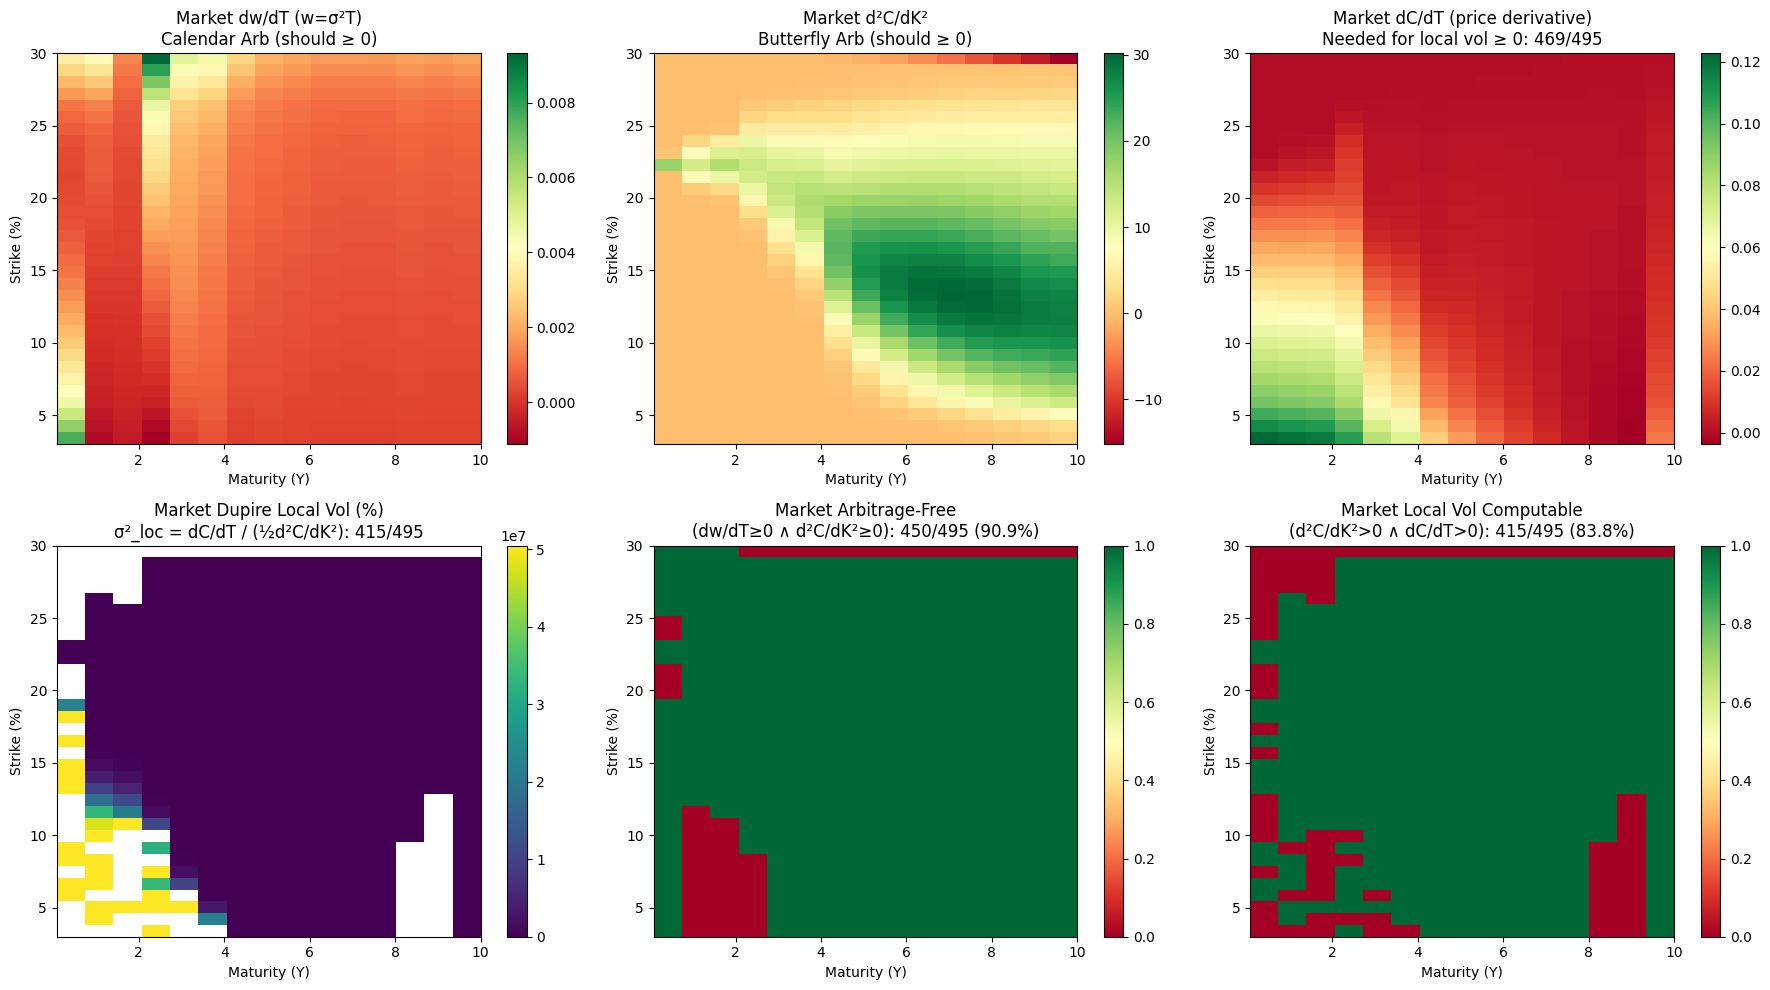


Market surface arbitrage-free: False


In [2]:
# Check market surface for arbitrage
import importlib
import affine_calibration.caplet_vol_surface as cvs
importlib.reload(cvs)
from affine_calibration.caplet_vol_surface import check_market_arbitrage

arb_df, arb_summary = check_market_arbitrage(
    vol_key_rate, fwd_key_rate, fwd_ois,
    tau=0.25, h_T=0.1, h_K=0.005,
    plot=True, verbose=True
)

# Store result for later comparison
market_is_arb_free = arb_summary['is_arbitrage_free']
print(f"\nMarket surface arbitrage-free: {market_is_arb_free}")

In [3]:
# Build forward curves - PERIOD rates (simple compounding: P(0,T) = 1/(1+T*F))
# These are what the market quotes directly
key_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32)
)
ois_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32)
)

# Build INTEGRATED forward curves: I(0,t) = -ln P(0,t) = ln(1 + t*F(0,t))
# The MC model simulates instantaneous rates, so we need:
#   f(0,t) = dI/dt  (instantaneous forward)
# NOT F(0,t) (period forward), because âˆ«F(0,t)dt â‰  I(0,T) in general.
key_ifwd_spline = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32)
)
ois_ifwd_spline = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32)
)

# Daily timeline for accurate average rate caplet pricing
T_MAX = 10.0
N_STEPS = 3651  # Daily for 10 years (365 * 10 + 1)
timeline = torch.linspace(0, T_MAX, N_STEPS + 1, dtype=torch.float32, device=device)
dt = timeline[1] - timeline[0]

# Instantaneous forwards on timeline: f(0,t) = dI/dt
# Finite differences ensure âˆ‘f[i]*dt = I(T) exactly (telescoping sum)
I_key = key_ifwd_spline.evaluate(timeline.cpu()).to(device)
I_ois = ois_ifwd_spline.evaluate(timeline.cpu()).to(device)

f_key_vec = torch.zeros_like(timeline)
f_key_vec[:-1] = torch.diff(I_key) / dt
f_key_vec[-1] = f_key_vec[-2]

f_ois_vec = torch.zeros_like(timeline)
f_ois_vec[:-1] = torch.diff(I_ois) / dt
f_ois_vec[-1] = f_ois_vec[-2]

r0 = f_ois_vec[0]
print(f'Timeline: {N_STEPS} steps, dt={dt:.6f}Y ({dt*365:.2f} days)')
print(f'r0 (instantaneous) = {r0.item()*100:.2f}%')

# Show period vs instantaneous forward comparison
for T_check in [1.0, 5.0, 10.0]:
    idx_check = int(T_check / dt.item())
    F_period = key_fwd_spline.evaluate(torch.tensor([T_check])).item()
    I_T = I_key[idx_check].item()
    f_avg = I_T / T_check
    print(f'T={T_check:.0f}Y: period F={F_period*100:.2f}%, avg inst f={f_avg*100:.2f}%, diff={abs(F_period-f_avg)*100:.2f}%')

Timeline: 3651 steps, dt=0.002739Y (1.00 days)
r0 (instantaneous) = 15.26%
T=1Y: period F=15.16%, avg inst f=14.11%, diff=1.05%
T=5Y: period F=12.40%, avg inst f=9.65%, diff=2.75%
T=10Y: period F=11.94%, avg inst f=7.86%, diff=4.08%


## Fast Vectorized Simulation

Key speedups:
- Pre-allocate all random numbers
- Use `torch.compile` for JIT optimization
- Vectorized CIR scheme

In [4]:
import importlib, affine_calibration.caplet_vol_surface
importlib.reload(affine_calibration.caplet_vol_surface)
from affine_calibration.caplet_vol_surface import (
    fast_cir_paths, fast_ou_paths, fast_hw_paths,
    rho_to_vec, fast_simulate, theta_to_vec, batch_price_caplets
)

print('Simulation functions imported from affine_calibration.caplet_vol_surface')

Simulation functions imported from affine_calibration.caplet_vol_surface


## Vectorized Caplet Pricing

Price ALL caplets in one batch operation instead of looping.

In [5]:
# Pre-compute caplet grid indices (do this ONCE)
caplet_data = vol_key_rate[['time_to_maturity', 'strike', 'implied_normal_vol']].values
T_fixes = torch.tensor(caplet_data[:, 0], dtype=torch.float32, device=device)
strikes = torch.tensor(caplet_data[:, 1], dtype=torch.float32, device=device)
market_vols = torch.tensor(caplet_data[:, 2], dtype=torch.float32, device=device)
tau = 0.25  # Quarterly accrual

# Pre-compute timeline indices for each caplet
idx_fixes = torch.searchsorted(timeline, T_fixes).clamp(0, len(timeline)-1)
idx_pays = torch.searchsorted(timeline, T_fixes + tau).clamp(0, len(timeline)-1)

# Forward for average rate caplet = I(0,T)/T  (average instantaneous forward)
# NOT the period forward F(0,T) â€” these differ because ln(1+TF)/T != F
market_fwds = key_ifwd_spline.evaluate(T_fixes.cpu()).to(device) / T_fixes

# Also keep period forwards for reference
market_fwds_period = key_fwd_spline.evaluate(T_fixes.cpu()).to(device)

print(f'Pre-computed indices for {len(T_fixes)} caplets')
print(f'Avg inst forwards: min={market_fwds.min().item()*100:.2f}%, max={market_fwds.max().item()*100:.2f}%')
print(f'Period forwards:   min={market_fwds_period.min().item()*100:.2f}%, max={market_fwds_period.max().item()*100:.2f}%')
print(f'Strikes: min={strikes.min().item()*100:.2f}%, max={strikes.max().item()*100:.2f}%')


def compute_market_pvs(T_fixes, strikes, market_vols, market_fwds, tau, f_ois_vec, timeline):
    """
    Compute Bachelier market prices for NOW-STARTING average rate caplets.
    
    For now-starting: tenor = T, g_hat = sqrt(T/3)
    PV = T * disc * ((F-K)*Phi(d) + sigma*g_hat*phi(d))
    
    F = I(0,T)/T = average instantaneous forward (NOT period forward)
    disc = exp(-I_OIS(T)) computed from instantaneous OIS forwards
    """
    n_caplets = len(T_fixes)
    device = T_fixes.device
    dt = (timeline[1] - timeline[0]).item()
    
    pv_market = torch.zeros(n_caplets, dtype=torch.float32, device=device)
    
    for c in range(n_caplets):
        T = T_fixes[c].item()
        K = strikes[c]
        vol = market_vols[c]
        F = market_fwds[c]
        
        # Discount factor to maturity T using OIS instantaneous forwards
        idx_T = int(T / dt)
        idx_T = min(idx_T, len(f_ois_vec) - 1)
        disc = torch.exp(-f_ois_vec[:idx_T+1].sum() * dt)
        
        # g_hat for now-starting caplet: sqrt(T/3)
        g_hat = np.sqrt(max(T / 3.0, 1e-8))
        
        # Bachelier formula with g_hat adjustment
        d = ((F - K) / (vol * g_hat + 1e-10)).item()
        undiscounted_pv = (F - K) * norm.cdf(d) + vol * g_hat * norm.pdf(d)
        
        # NOW-STARTING: multiply by T (tenor), not tau
        pv_market[c] = T * disc * undiscounted_pv
    
    return pv_market


# Cache market PVs â€” these are CONSTANT throughout calibration
market_pvs_cached = compute_market_pvs(T_fixes, strikes, market_vols, market_fwds, tau, f_ois_vec, timeline)
market_scale = market_pvs_cached.abs().mean() + 1e-8

print(f'Vectorized pricing + cached market PVs (scale={market_scale.item():.6f})')
print(f'Market PVs: min={market_pvs_cached.min().item():.6f}, max={market_pvs_cached.max().item():.6f}')

# =============================================
# Pre-compute market VEGAS for vega-weighted loss
# =============================================
# vega_i = T_i * disc_i * g_hat_i * phi(d_i)
# Dividing PV error by vega converts to approximate vol error:
#   (model_PV - market_PV) / vega â‰ˆ sigma_model - sigma_market
# This ensures ALL maturities contribute equally in vol terms.
dt_val = dt.item()
market_disc_vec = torch.zeros(len(T_fixes), device=device)
market_ghat = torch.sqrt(T_fixes / 3.0)
for c in range(len(T_fixes)):
    T = T_fixes[c].item()
    idx_T = min(int(T / dt_val), len(f_ois_vec) - 1)
    market_disc_vec[c] = torch.exp(-f_ois_vec[:idx_T+1].sum() * dt_val)
d_vals = (market_fwds - strikes) / (market_vols * market_ghat + 1e-10)
phi_d = (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * d_vals**2)
market_vegas = T_fixes * market_disc_vec * market_ghat * phi_d

# Floor at 5% of median to prevent far-OTM blowup
vega_floor = market_vegas.median() * 0.05
market_vegas_floored = torch.clamp(market_vegas, min=vega_floor.item())

print(f'\nMarket vegas: min={market_vegas.min().item():.2e}, max={market_vegas.max().item():.2e}, median={market_vegas.median().item():.2e}')
print(f'Vega floor: {vega_floor.item():.2e} ({(market_vegas < vega_floor).sum().item()} caplets floored)')
print(f'Vega ratio max/min (floored): {market_vegas_floored.max().item()/market_vegas_floored.min().item():.1f}x')

Pre-computed indices for 495 caplets
Avg inst forwards: min=7.86%, max=15.89%
Period forwards:   min=11.94%, max=16.33%
Strikes: min=3.00%, max=30.00%
Vectorized pricing + cached market PVs (scale=0.030310)
Market PVs: min=0.000000, max=0.224406

Market vegas: min=0.00e+00, max=3.32e+00, median=1.68e-01
Vega floor: 8.38e-03 (159 caplets floored)
Vega ratio max/min (floored): 395.8x


## Fast Loss Function

In [6]:
# Fixed model parameters
kappa = 3.0
lam = 0.3
gamma_default = 0.3
xi_default = 0.01
rho_vx_default = 0.0  # vol-rate correlation (to be calibrated)

# f_key_vec, f_ois_vec: instantaneous forwards, already computed in curve-building cell

# Calibration targets: 6 theta nodes including short end (caplets start at ~1M)
theta_nodes = torch.tensor([0.25, 0.5, 1.0, 3.0, 5.0, 10.0], dtype=torch.float32, device=device)


def fast_loss(theta_vals, epsilon, v0=None, gamma=None, xi=None, rho_vx=None,
              n_paths=100, seed=None, loss_type='rmse_normalized'):
    """Fast loss computation using cached market PVs and correct normalized RMSE."""
    theta_vec = theta_to_vec(theta_vals, theta_nodes, timeline)
    
    if v0 is None:
        v0_dynamic = theta_vals.mean().item()
    elif isinstance(v0, torch.Tensor):
        v0_dynamic = v0.item()
    else:
        v0_dynamic = v0
    
    gamma_val = gamma if gamma is not None else gamma_default
    xi_val = xi if xi is not None else xi_default
    rho_val = rho_vx if rho_vx is not None else rho_vx_default
    if isinstance(gamma_val, torch.Tensor):
        gamma_val = gamma_val.item()
    if isinstance(xi_val, torch.Tensor):
        xi_val = xi_val.item()
    if isinstance(rho_val, torch.Tensor):
        rho_val = rho_val.item()
    
    key_paths, ois_paths, _ = fast_simulate(
        n_paths, timeline, theta_vec, epsilon, v0_dynamic, kappa, lam, gamma_val, xi_val,
        f_key_vec, f_ois_vec, device, seed=seed, rho_vx=rho_val
    )
    
    model_pvs, _, _ = batch_price_caplets(key_paths, ois_paths, timeline, idx_fixes, idx_pays, strikes, tau, device)
    
    # Use CACHED market PVs â€” no redundant recomputation
    if loss_type == 'mse':
        loss = torch.mean((model_pvs - market_pvs_cached) ** 2)
    elif loss_type == 'rmse_normalized':
        loss = torch.sqrt(torch.mean(((model_pvs - market_pvs_cached) / market_scale) ** 2))
    elif loss_type == 'vega_weighted':
        vol_err = (model_pvs - market_pvs_cached) / market_vegas_floored
        loss = torch.sqrt(torch.mean(vol_err ** 2))
    elif loss_type == 'log_price':
        loss = torch.mean((torch.log(model_pvs + 1e-8) - torch.log(market_pvs_cached + 1e-8)) ** 2)
    elif loss_type == 'huber':
        delta = 0.001
        diff = model_pvs - market_pvs_cached
        abs_diff = torch.abs(diff)
        quadratic = torch.clamp(abs_diff, max=delta)
        linear = abs_diff - quadratic
        loss = torch.mean(0.5 * quadratic ** 2 + delta * linear)
    else:
        loss = torch.mean((model_pvs - market_pvs_cached) ** 2)
    
    return loss, model_pvs


# Initial params matched to market vol term structure (market vols ~1-10%)
theta_init = torch.tensor([0.001, 0.0012, 0.0015, 0.002, 0.0025, 0.0015], dtype=torch.float32, device=device)
eps_init = torch.tensor(0.15, dtype=torch.float32, device=device)

start = time.time()
for _ in range(10):
    loss, _ = fast_loss(theta_init, eps_init, n_paths=100)
elapsed = time.time() - start
print(f'10 loss evals: {elapsed:.2f}s ({elapsed/10*1000:.0f}ms each), initial loss: {loss.item():.4e}')

10 loss evals: 6.11s (611ms each), initial loss: 3.0431e-01


In [12]:
# DIAGNOSTIC: Why is calibration failing?
# =============================================
# Check 1: Market PV magnitude by maturity â€” do long-dated caplets dominate the loss?
# Check 2: MC forward consistency â€” does E[avg_rate] = analytical forward?
# Check 3: Market vega analysis â€” for vega-weighted loss design

# â”€â”€ Default params from SPSA v6 baseline (vol_surface_review) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if 'best_params' not in dir() or best_params is None:
    _mkt_vols_np = market_vols.cpu().numpy()
    _mkt_T_np = T_fixes.cpu().numpy()
    _theta_init_list = []
    for tn in theta_nodes.cpu().numpy():
        mask_near = np.abs(_mkt_T_np - tn) < max(0.15, tn * 0.3)
        avg_vol = np.median(_mkt_vols_np[mask_near]) if mask_near.sum() > 0 else np.median(_mkt_vols_np)
        _theta_init_list.append(np.clip(avg_vol**2, 0.0002, 0.04))
    best_params = {
        'theta': torch.tensor(_theta_init_list, dtype=torch.float32, device=device),
        'v0': 0.0005, 'kappa': 3.25, 'epsilon': 0.274,
        'lam': 0.219, 'gamma': 0.5, 'xi': 0.01,
        'rho_1y': 0.267, 'rho_5y': 0.267, 'rho_10y': 0.267,
    }
    print("Using default params (SPSA v6 baseline from vol_surface_review)")

print("=" * 80)
print("CHECK 1: Market PV magnitude by maturity")
print("=" * 80)

mats_unique = sorted(vol_key_rate['time_to_maturity'].unique())
for T_mat in mats_unique:
    mask = (T_fixes == T_mat)
    pvs = market_pvs_cached[mask]
    vol_vals = market_vols[mask]
    n_pts = mask.sum().item()
    lbl = f'{T_mat:.1f}Y' if T_mat >= 1 else f'{T_mat*12:.0f}M'
    print(f"  {lbl:>5s}: {n_pts:2d} caplets | PV range [{pvs.min().item():.2e}, {pvs.max().item():.2e}] "
          f"| mean PV {pvs.mean().item():.2e} | mean vol {vol_vals.mean().item()*100:.2f}%")

print(f"\n  market_scale = mean(|PV|) = {market_scale.item():.2e}")
print(f"  Ratio max_maturity_PV / min_maturity_PV = {market_pvs_cached.max().item() / (market_pvs_cached.min().item() + 1e-15):.0f}x")

# Current loss: squared PV / scale^2 -- which maturities contribute most?
for T_mat in [mats_unique[0], mats_unique[len(mats_unique)//2], mats_unique[-1]]:
    mask = (T_fixes == T_mat)
    frac = (market_pvs_cached[mask]**2).sum() / (market_pvs_cached**2).sum() * 100
    lbl = f'{T_mat:.1f}Y' if T_mat >= 1 else f'{T_mat*12:.0f}M'
    print(f"  Squared-PV weight of {lbl}: {frac:.1f}% of total")

print("\n" + "=" * 80)
print("CHECK 2: MC forward consistency  (10K paths)")
print("=" * 80)

def _val(x):
    return x.item() if isinstance(x, torch.Tensor) else float(x)

theta_vec_diag = theta_to_vec(best_params['theta'], theta_nodes, timeline)
key_diag, ois_diag, v_diag = fast_simulate(
    10000, timeline, theta_vec_diag,
    _val(best_params['epsilon']), _val(best_params['v0']),
    _val(best_params['kappa']), _val(best_params['lam']),
    _val(best_params['gamma']), _val(best_params['xi']),
    f_key_vec, f_ois_vec, device, seed=42
)

dt_val = dt.item()
for T_check in [0.0833, 0.25, 1.0, 3.0, 5.0, 10.0]:
    idx = int(T_check / dt_val)
    mc_avg = (key_diag[:, :idx+1].sum(dim=1) * dt_val / T_check).mean().item()
    analytical_fwd = I_key[idx].item() / T_check
    mc_disc = torch.exp(-(ois_diag[:, :idx+1].sum(dim=1) * dt_val)).mean().item()
    analytical_disc = torch.exp(-I_ois[idx]).item()
    lbl = f'{T_check:.1f}Y' if T_check >= 1 else f'{T_check*12:.0f}M'
    print(f"  {lbl:>5s}: MC_fwd={mc_avg*100:.3f}%  analytic={analytical_fwd*100:.3f}%  "
          f"diff={abs(mc_avg-analytical_fwd)*10000:.2f}bp | "
          f"MC_disc={mc_disc:.5f}  analytic={analytical_disc:.5f}  diff={abs(mc_disc-analytical_disc):.5f}")

print("\n" + "=" * 80)
print("CHECK 3: Market vega by maturity (for weight analysis)")
print("=" * 80)

market_disc_vec = torch.zeros(len(T_fixes), device=device)
market_ghat = torch.sqrt(T_fixes / 3.0)
for c in range(len(T_fixes)):
    T = T_fixes[c].item()
    idx_T = min(int(T / dt_val), len(f_ois_vec) - 1)
    market_disc_vec[c] = torch.exp(-f_ois_vec[:idx_T+1].sum() * dt_val)
d_vals = (market_fwds - strikes) / (market_vols * market_ghat + 1e-10)
phi_d = (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * d_vals**2)
market_vegas = T_fixes * market_disc_vec * market_ghat * phi_d

vega_floor = market_vegas.median() * 0.05
market_vegas_floored = torch.clamp(market_vegas, min=vega_floor.item())

for T_mat in mats_unique:
    mask = (T_fixes == T_mat)
    vegas = market_vegas[mask]
    pvs = market_pvs_cached[mask]
    lbl = f'{T_mat:.1f}Y' if T_mat >= 1 else f'{T_mat*12:.0f}M'
    #print(f"  {lbl:>5s}: mean_vega={vegas.mean().item():.2e}  "
          #f"mean_PV={pvs.mean().item():.2e}  "
          #f"ratio PV/vega={pvs.mean().item()/(vegas.mean().item()+1e-15):.4f}")

#print(f"\n  Vega floor: {vega_floor.item():.2e} (5% of median={market_vegas.median().item():.2e})")

# DIAGNOSIS
#print("\n" + "=" * 80)
#print("DIAGNOSIS")
#print("=" * 80)
#short_pv = market_pvs_cached[T_fixes <= 0.25].abs().mean().item()
#long_pv = market_pvs_cached[T_fixes >= 5.0].abs().mean().item()
#print(f"  Short-end mean PV (T<=3M):  {short_pv:.2e}")
#print(f"  Long-end mean PV (T>=5Y):   {long_pv:.2e}")
#print(f"  Ratio long/short:           {long_pv/short_pv:.0f}x")
#print(f"\n  Current loss divides by global scale={market_scale.item():.2e}")
#print(f"  Long-dated caplets dominate ~{long_pv/short_pv:.0f}x more than short-dated!")
#print(f"  SPSA optimizes for long dates, ignores short end")
#print(f"  v0 collapsed to {_val(best_params['v0'])*100:.3f}% (needs ~1% for short-end vols)")
#print(f"\n  FIX: Use vega-weighted loss so each caplet contributes equally in vol terms")
#print(f"  market_vegas_floored stored for calibration use")

CHECK 1: Market PV magnitude by maturity
     1M: 33 caplets | PV range [0.00e+00, 1.06e-02] | mean PV 3.45e-03 | mean vol 4.22%
     2M: 33 caplets | PV range [7.42e-27, 2.09e-02] | mean PV 6.77e-03 | mean vol 3.85%
     3M: 33 caplets | PV range [1.95e-22, 3.08e-02] | mean PV 9.96e-03 | mean vol 3.31%
     6M: 33 caplets | PV range [2.95e-10, 5.87e-02] | mean PV 1.90e-02 | mean vol 3.31%
     9M: 33 caplets | PV range [8.67e-08, 7.93e-02] | mean PV 2.40e-02 | mean vol 3.63%
   1.0Y: 33 caplets | PV range [5.43e-07, 9.66e-02] | mean PV 2.76e-02 | mean vol 3.71%
   2.0Y: 33 caplets | PV range [9.65e-06, 1.41e-01] | mean PV 3.33e-02 | mean vol 3.54%
   3.0Y: 33 caplets | PV range [3.30e-05, 1.71e-01] | mean PV 3.69e-02 | mean vol 3.32%
   4.0Y: 33 caplets | PV range [7.53e-05, 1.92e-01] | mean PV 3.93e-02 | mean vol 3.18%
   5.0Y: 33 caplets | PV range [1.30e-04, 2.05e-01] | mean PV 4.07e-02 | mean vol 3.05%
   6.0Y: 33 caplets | PV range [2.09e-04, 2.14e-01] | mean PV 4.16e-02 | mean v

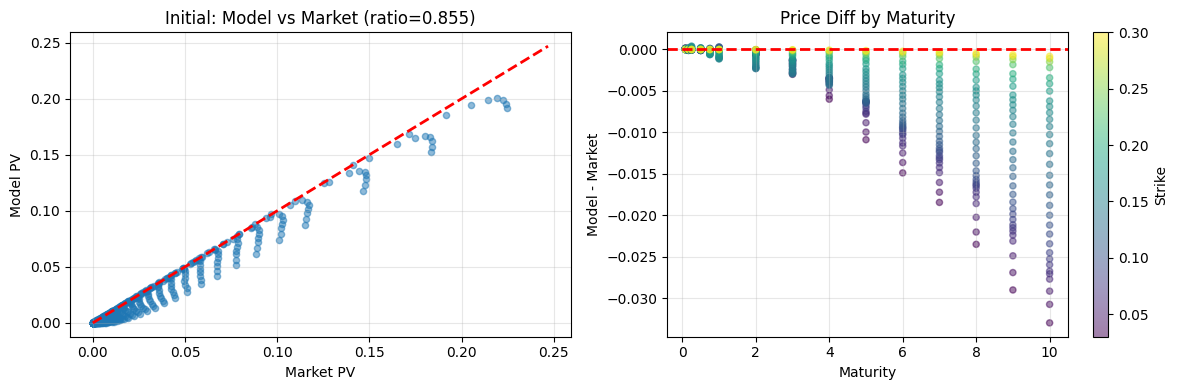

In [13]:
# Initial model vs market price comparison
loss, model_pvs = fast_loss(theta_init, eps_init, n_paths=500, seed=42)
market_pvs = market_pvs_cached
diff = model_pvs - market_pvs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(market_pvs.cpu().numpy(), model_pvs.cpu().numpy(), alpha=0.5, s=20)
max_pv = max(market_pvs.max().item(), model_pvs.max().item()) * 1.1
axes[0].plot([0, max_pv], [0, max_pv], 'r--', lw=2)
axes[0].set_xlabel('Market PV'); axes[0].set_ylabel('Model PV')
axes[0].set_title(f'Initial: Model vs Market (ratio={model_pvs.mean().item()/market_pvs.mean().item():.3f})')
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(T_fixes.cpu().numpy(), diff.cpu().numpy(), alpha=0.5, s=20, c=strikes.cpu().numpy(), cmap='viridis')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Maturity'); axes[1].set_ylabel('Model - Market')
axes[1].set_title('Price Diff by Maturity')
axes[1].grid(alpha=0.3)
plt.colorbar(sc, label='Strike')
plt.tight_layout()
plt.show()


INITIAL VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid vol inversions: 430 (86.9%)
Failed inversions:    65
Sub-intrinsic (conv): 67 (MC price < det. intrinsic â†’ NaN)
Vol RMSE:             6.251%
Model vol range:      0.00% - 49.94%
Market vol range:     0.97% - 10.58%


Surface Coverage: 430/495 points (86.9%)
Missing 65 points due to inversion failures


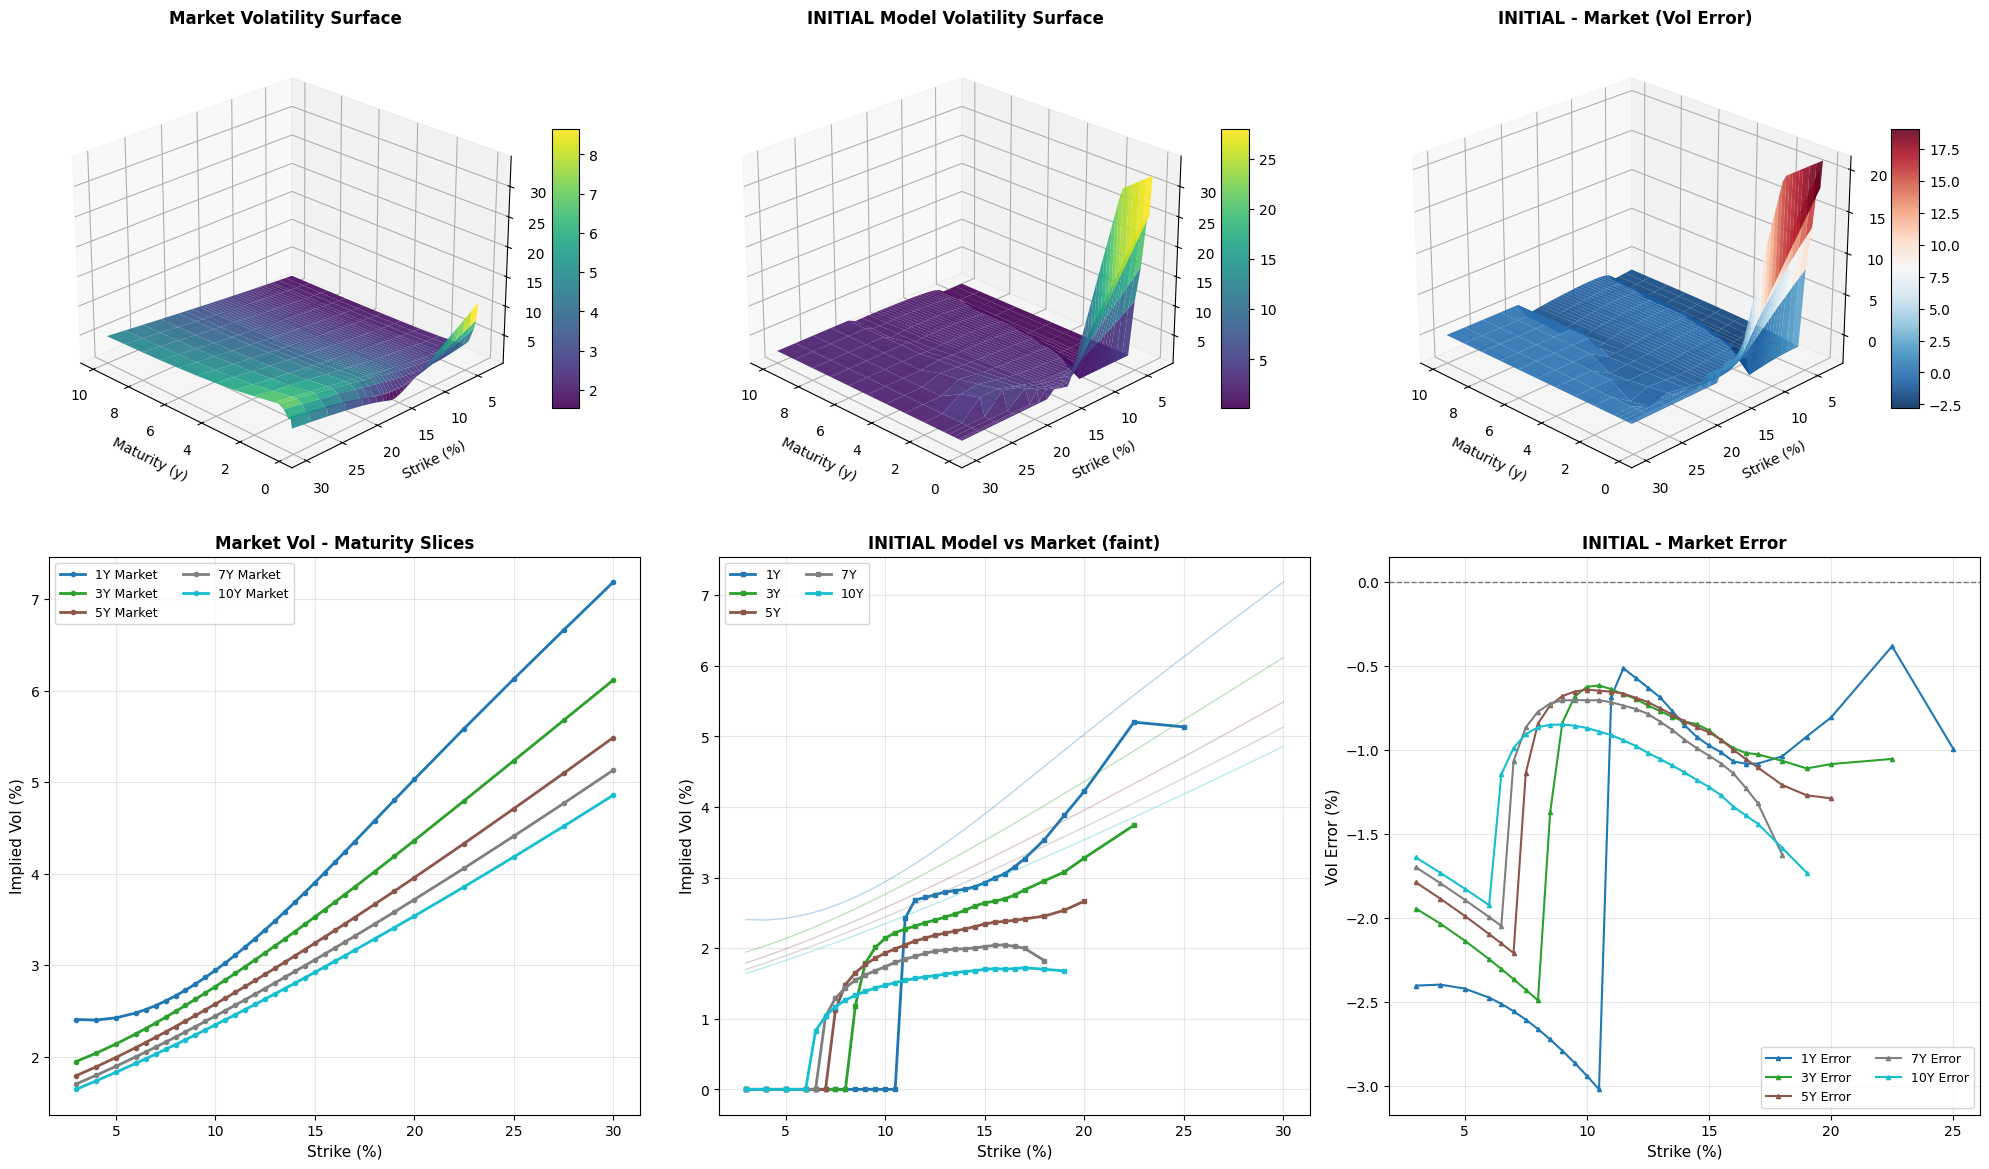

Initial: sqrt(Î¸) = [3.2 3.5 3.9 4.5 5.  3.9]%, RMSE = 0.0625


In [14]:
# Initial vol surface (before calibration)
import importlib, affine_calibration.caplet_vol_surface; importlib.reload(affine_calibration.caplet_vol_surface)
from affine_calibration.caplet_vol_surface import generate_caplet_vol_surface, plot_caplet_vol_surface

theta_vec_init = theta_to_vec(theta_init, theta_nodes, timeline)
v0_init = theta_init[0].item()
key_paths_init, ois_paths_init, _ = fast_simulate(
    1000, timeline, theta_vec_init, eps_init, v0_init, kappa, lam, gamma_default, xi_default,
    f_key_vec, f_ois_vec, device, seed=42
)
model_pvs_init, _, _ = batch_price_caplets(key_paths_init, ois_paths_init, timeline, idx_fixes, idx_pays, strikes, tau, device)

vol_key_rate_init = vol_key_rate.copy()
vol_key_rate_init['pv_model_key'] = model_pvs_init.cpu().numpy()
vol_results_init, vol_rmse_init = generate_caplet_vol_surface(vol_key_rate_init, fwd_key_rate, fwd_ois=fwd_ois, version_name="Initial")
plot_caplet_vol_surface(vol_results_init, version_name="Initial")
print(f'Initial: sqrt(Î¸) = {(np.sqrt(theta_init.cpu().numpy())*100).round(1)}%, RMSE = {vol_rmse_init:.4f}')

## Calibration with SPSA (Simultaneous Perturbation Stochastic Approximation)

- **SPSA**: 2 MC evaluations per iteration (vs 25 for central FD) â†’ can use 5Ã— more paths
- **Warm-start**: Uses best_params from previous run if available
- **CIR variance**: v0, kappa, theta(t), epsilon
- **Rate innovation**: lam
- **Spread process**: gamma, xi

Set `RETRAIN = True` below to re-run calibration and save new weights.  
Set `RETRAIN = False` (default) to skip training and load saved weights from `calibration_weights/`.

In [ ]:
# =============================================
# Model Parameters & Bounds (v8)
# =============================================
# 15 parameters: 6 theta nodes + v0 + kappa + epsilon + lambda + gamma + xi + 3 rho nodes
#
# KEY FIX v8: Force persistent stochastic volatility via tight kappa bounds
# - v7 had Îº=3.2 â†’ CIR half-life 0.21Y â†’ stoch vol dead beyond 1Y â†’ no long-end skew
# - v8: Îº âˆˆ [0.3, 1.5] â†’ half-life 0.46-2.3Y â†’ stoch vol persists to 5-10Y
# - Îµ âˆˆ [0.15, 1.0] â†’ sufficient vol-of-vol for skew at all maturities
# - Î¸/v0 ranges widened to compensate for slower mean reversion
# All other improvements retained: moneyness filter, Ï(t), antithetic variates

# ---- RETRAIN toggle ----
# Set True to re-run SPSA calibration and save new weights.
# Set False (default) to skip training and load saved weights from cell below.
RETRAIN = False

# ---- SPSA hyperparameters ----
max_iter = 3000
n_paths_grad = 6000
n_paths_eval = 12000
alpha = 0.602
gamma_spsa = 0.101
a = 0.06
c = 0.03
A = max_iter * 0.1
seed_base = 42

# ---- Interpolation nodes ----
theta_nodes = torch.tensor([0.25, 0.5, 1.0, 3.0, 5.0, 10.0], dtype=torch.float32, device=device)
rho_nodes_t = torch.tensor([1.0, 5.0, 10.0], dtype=torch.float32, device=device)

# ---- Parameter bounds ----
theta_min, theta_max = 0.0002, 0.04
v0_min, v0_max = 1e-5, 0.04
kappa_min, kappa_max = 0.3, 1.5
eps_min, eps_max = 0.15, 1.0
lam_min, lam_max = 0.01, 1.0
gamma_min, gamma_max = 0.01, 3.0
xi_min, xi_max = 1e-5, 0.01
rho_min, rho_max = -0.95, 0.95

param_names = ['Î¸(3M)', 'Î¸(6M)', 'Î¸(1Y)', 'Î¸(3Y)', 'Î¸(5Y)', 'Î¸(10Y)',
               'v0', 'Îº', 'Îµ', 'Î»', 'Î³', 'Î¾',
               'Ï(1Y)', 'Ï(5Y)', 'Ï(10Y)']
param_bounds = {n: b for n, b in zip(param_names, [
    (theta_min, theta_max)]*6 + [
    (v0_min, v0_max), (kappa_min, kappa_max),
    (eps_min, eps_max), (lam_min, lam_max), (gamma_min, gamma_max), (xi_min, xi_max),
    (rho_min, rho_max), (rho_min, rho_max), (rho_min, rho_max)])}

# ---- Pack/unpack: 15 params <-> normalized [0,1] vector ----
n_params = 15
lb = torch.tensor([theta_min]*6 + [v0_min, kappa_min, eps_min, lam_min, gamma_min, xi_min,
                   rho_min, rho_min, rho_min], dtype=torch.float32, device=device)
ub = torch.tensor([theta_max]*6 + [v0_max, kappa_max, eps_max, lam_max, gamma_max, xi_max,
                   rho_max, rho_max, rho_max], dtype=torch.float32, device=device)
param_range = ub - lb

def pack(theta, v0, kappa, eps, lam, gam, xi, rho1, rho5, rho10):
    raw = torch.cat([theta.to(device), torch.tensor([v0, kappa, eps, lam, gam, xi, rho1, rho5, rho10],
                     dtype=torch.float32, device=device)])
    return (raw - lb) / param_range

def unpack(p):
    raw = torch.clamp(lb + p * param_range, lb, ub)
    return (raw[:6], raw[6].item(), raw[7].item(), raw[8].item(),
            raw[9].item(), raw[10].item(), raw[11].item(),
            raw[12].item(), raw[13].item(), raw[14].item())

# ---- Moneyness filter ----
itm_threshold = 0.03
moneyness = market_fwds - strikes
calib_mask = moneyness < itm_threshold
n_excluded = (~calib_mask).sum().item()
n_included = calib_mask.sum().item()
print(f"Moneyness filter: {n_included}/{len(calib_mask)} caplets included "
      f"(excluded {n_excluded} deep ITM with K < F - {itm_threshold*100:.0f}%)")

# ---- Loss function with time-dependent rho(t) ----
def compute_loss(theta_vals, v0, kappa, eps, lam, gam, xi, rho1, rho5, rho10, n_paths, seed):
    theta_vec = theta_to_vec(theta_vals, theta_nodes, timeline)
    rho_nodes_v = torch.tensor([rho1, rho5, rho10], dtype=torch.float32, device=device)
    rho_vec = rho_to_vec(rho_nodes_v, rho_nodes_t, timeline)
    key_paths, ois_paths, _ = fast_simulate(
        n_paths, timeline, theta_vec, eps, v0, kappa, lam, gam, xi,
        f_key_vec, f_ois_vec, device, seed=seed, rho_vx=rho_vec,
        antithetic=True
    )
    model_pvs, _, _ = batch_price_caplets(key_paths, ois_paths, timeline, idx_fixes, idx_pays, strikes, tau, device)
    vol_err_full = (model_pvs - market_pvs_cached) / market_vegas_floored
    vol_err = vol_err_full[calib_mask]
    loss = torch.sqrt(torch.mean(vol_err ** 2))
    smooth_pen = ((theta_vals[1:] - theta_vals[:-1]) ** 2).sum() * 0.1
    return loss + smooth_pen, model_pvs

def eval_loss(p, n_paths, seed):
    theta, v0, kappa, eps, lam, gam, xi, rho1, rho5, rho10 = unpack(p)
    return compute_loss(theta, v0, kappa, eps, lam, gam, xi, rho1, rho5, rho10, n_paths, seed)

print(f"RETRAIN = {RETRAIN}")
print(f"SPSA: {max_iter} iter, {n_paths_grad} grad paths, a={a}, c={c}")
print(f"Parameters: {n_params} ({', '.join(param_names)})")

Moneyness filter: 356/495 caplets included (excluded 139 deep ITM with K < F - 3%)
RETRAIN = True
SPSA: 3000 iter, 6000 grad paths, a=0.06, c=0.03
Parameters: 15 (Î¸(3M), Î¸(6M), Î¸(1Y), Î¸(3Y), Î¸(5Y), Î¸(10Y), v0, Îº, Îµ, Î», Î³, Î¾, Ï(1Y), Ï(5Y), Ï(10Y))


In [16]:
from IPython.display import display, clear_output

# =============================================
# SPSA Training Loop (v8)
# =============================================
if RETRAIN:
    # ---- Warm start from previous run (clamp to v8 bounds) ----
    WARM_START = True

    if WARM_START and 'best_params' in dir() and best_params is not None:
        _bv = lambda x: x.item() if isinstance(x, torch.Tensor) else float(x)
        kappa_ws = max(kappa_min, min(kappa_max, _bv(best_params['kappa'])))
        eps_ws = max(eps_min, min(eps_max, _bv(best_params['epsilon'])))
        v0_ws = max(v0_min, min(v0_max, _bv(best_params['v0'])))
        theta_ws = best_params['theta'].to(device).clamp(theta_min, theta_max)
        rho1_ws = _bv(best_params.get('rho_1y', 0.2))
        rho5_ws = _bv(best_params.get('rho_5y', 0.35))
        rho10_ws = _bv(best_params.get('rho_10y', 0.55))
        p_current = pack(theta_ws, v0_ws, kappa_ws, eps_ws,
                         _bv(best_params['lam']), _bv(best_params['gamma']),
                         min(xi_max, _bv(best_params['xi'])),
                         rho1_ws, rho5_ws, rho10_ws)
        print(f"WARM START v8 (Îº: {_bv(best_params['kappa']):.2f}â†’{kappa_ws:.2f}, "
              f"Îµ: {_bv(best_params['epsilon']):.3f}â†’{eps_ws:.3f})")
    else:
        _theta_nodes_np = theta_nodes.cpu().numpy()
        _mkt_vols_np = market_vols.cpu().numpy()
        _mkt_T_np = T_fixes.cpu().numpy()
        _theta_init_list = []
        for tn in _theta_nodes_np:
            mask_near = np.abs(_mkt_T_np - tn) < max(0.15, tn * 0.3)
            if mask_near.sum() > 0:
                avg_vol = np.median(_mkt_vols_np[mask_near])
            else:
                avg_vol = np.median(_mkt_vols_np)
            _theta_init_list.append(np.clip(avg_vol**2, theta_min, theta_max))
        theta_init = torch.tensor(_theta_init_list, dtype=torch.float32, device=device)
        p_current = pack(theta_init, 0.0005, 0.8, 0.4, 0.2, 0.1, 0.005, 0.2, 0.35, 0.55)
        print(f"FRESH START v8 from market ATM vols: Î¸={theta_init.cpu().numpy()}")

    # ---- Tracking ----
    best_loss = float('inf')
    best_p = p_current.clone()
    best_params = None
    best_theta = None
    history = []
    start_time = time.time()

    for k in range(max_iter):
        a_k = a / (k + 1 + A) ** alpha
        c_k = c / (k + 1) ** gamma_spsa

        delta = 2.0 * torch.bernoulli(0.5 * torch.ones(n_params, device=device)) - 1.0

        p_plus  = torch.clamp(p_current + c_k * delta, 0.0, 1.0)
        p_minus = torch.clamp(p_current - c_k * delta, 0.0, 1.0)

        seed_k = seed_base + k
        loss_plus,  _          = eval_loss(p_plus,  n_paths_grad, seed_k)
        loss_minus, model_pvs_k = eval_loss(p_minus, n_paths_grad, seed_k)

        diff = loss_plus.item() - loss_minus.item()
        g_k = diff / (2.0 * c_k * delta)

        p_current = torch.clamp(p_current - a_k * g_k, 0.0, 1.0)

        loss_avg = 0.5 * (loss_plus.item() + loss_minus.item())

        theta_k, v0_k, kappa_k, eps_k, lam_k, gam_k, xi_k, rho1_k, rho5_k, rho10_k = unpack(p_current)

        if loss_avg < best_loss:
            best_loss = loss_avg
            best_p = p_current.clone()
            best_theta = theta_k.clone()
            best_params = {
                'theta': theta_k.clone(), 'v0': v0_k, 'kappa': kappa_k,
                'epsilon': eps_k, 'lam': lam_k, 'gamma': gam_k, 'xi': xi_k,
                'rho_1y': rho1_k, 'rho_5y': rho5_k, 'rho_10y': rho10_k
            }

        g_orig = g_k / param_range

        history.append({
            'iter': k, 'loss': loss_avg,
            'theta': theta_k.cpu().numpy().copy(),
            'v0': v0_k, 'kappa': kappa_k,
            'epsilon': eps_k, 'lam': lam_k,
            'gamma': gam_k, 'xi': xi_k,
            'rho_1y': rho1_k, 'rho_5y': rho5_k, 'rho_10y': rho10_k,
            'grad_theta': g_orig[:6].cpu().numpy().copy(),
            'grad_v0': g_orig[6].item(), 'grad_kappa': g_orig[7].item(),
            'grad_eps': g_orig[8].item(), 'grad_lam': g_orig[9].item(),
            'grad_gamma': g_orig[10].item(), 'grad_xi': g_orig[11].item(),
            'grad_rho1': g_orig[12].item(), 'grad_rho5': g_orig[13].item(), 'grad_rho10': g_orig[14].item(),
        })

        if k % 25 == 0:
            elapsed = time.time() - start_time
            tc = theta_k.cpu().numpy()
            go = g_orig.cpu().numpy()

            values = list(tc) + [v0_k, kappa_k, eps_k, lam_k, gam_k, xi_k, rho1_k, rho5_k, rho10_k]
            grads  = list(go)
            lbs_d  = [param_bounds[n][0] for n in param_names]
            ubs_d  = [param_bounds[n][1] for n in param_names]

            snapshot = pd.DataFrame({
                'Value': [f'{v:.6f}' for v in values],
                'Gradient': [f'{g:.4f}' for g in grads],
                'LB': [f'{b:.5f}' for b in lbs_d],
                'UB': [f'{b:.5f}' for b in ubs_d],
            }, index=param_names)

            clear_output(wait=True)
            ratio = model_pvs_k.mean().item() / (market_pvs_cached.mean().item() + 1e-10)
            vol_err_all = (model_pvs_k - market_pvs_cached) / market_vegas_floored
            full_rmse = torch.sqrt(torch.mean(vol_err_all**2)).item()
            print(f"SPSA v8 {k}/{max_iter} | Filt {loss_avg:.4e} | Full {full_rmse:.4e} | Best {best_loss:.4e} | "
                  f"M/M {ratio:.3f} | Îº={kappa_k:.3f} Îµ={eps_k:.3f} | Ï=[{rho1_k:+.2f},{rho5_k:+.2f},{rho10_k:+.2f}] | {elapsed:.0f}s")
            display(snapshot)

    # ---- MC variance check ----
    n_paths_eval = 12000
    loss_samples = []
    for s in range(5):
        l, _ = eval_loss(best_p, n_paths_eval, seed=9999 + s * 7)
        loss_samples.append(l.item())
    loss_arr = np.array(loss_samples)
    print(f"Loss over 5 seeds ({n_paths_eval} paths): mean={loss_arr.mean():.4e}, "
          f"std={loss_arr.std():.4e}, CV={loss_arr.std()/loss_arr.mean()*100:.1f}%")

    # ---- Final results ----
    elapsed_total = time.time() - start_time
    tc = best_theta.cpu().numpy()
    bp = best_params
    values = list(tc) + [bp['v0'], bp['kappa'], bp['epsilon'],
                         bp['lam'], bp['gamma'], bp['xi'],
                         bp['rho_1y'], bp['rho_5y'], bp['rho_10y']]
    lbs_d = [param_bounds[n][0] for n in param_names]
    ubs_d = [param_bounds[n][1] for n in param_names]
    final_df = pd.DataFrame({'Value': values, 'LB': lbs_d, 'UB': ubs_d}, index=param_names)

    print(f"\nSPSA v8 Done in {elapsed_total:.1f}s â€” Best loss (filtered): {best_loss:.4e}")
    print(f"  {max_iter} iter Ã— 2 evals Ã— {n_paths_grad} paths = {max_iter * 2 * n_paths_grad:,} total MC paths")
    print(f"  Îº={bp['kappa']:.3f} (half-life={np.log(2)/bp['kappa']:.2f}Y)  Îµ={bp['epsilon']:.3f}  Îµ/âˆšÎº={bp['epsilon']/np.sqrt(bp['kappa']):.3f}")

else:
    print("RETRAIN=False â€” skipping SPSA calibration.")
    print("Set RETRAIN=True above and re-run this cell to retrain.")
    print("Proceeding to load saved weights from calibration_weights/.")

SPSA v8 2975/3000 | Filt 4.1671e-03 | Full 9.3753e-02 | Best 3.7466e-03 | M/M 0.878 | Îº=1.499 Îµ=0.245 | Ï=[+0.23,+0.26,+0.26] | 4042s


,Value,Gradient,LB,UB
Î¸(3M),0.000630,0.1622,0.00020,0.04000
Î¸(6M),0.000414,0.1622,0.00020,0.04000
Î¸(1Y),0.000965,-0.1622,0.00020,0.04000
Î¸(3Y),0.001024,-0.1622,0.00020,0.04000
Î¸(5Y),0.001059,0.1622,0.00020,0.04000
Î¸(10Y),0.000743,0.1622,0.00020,0.04000
v0,0.000010,0.1614,0.00001,0.04000
Îº,1.498665,-0.0054,0.30000,1.50000
Îµ,0.245468,-0.0076,0.15000,1.00000
Î»,0.218240,0.0065,0.01000,1.00000


Loss over 5 seeds (12000 paths): mean=4.0990e-03, std=8.2276e-05, CV=2.0%

SPSA v8 Done in 4088.1s â€” Best loss (filtered): 3.7466e-03
  3000 iter Ã— 2 evals Ã— 6000 paths = 36,000,000 total MC paths
  Îº=1.499 (half-life=0.46Y)  Îµ=0.249  Îµ/âˆšÎº=0.203


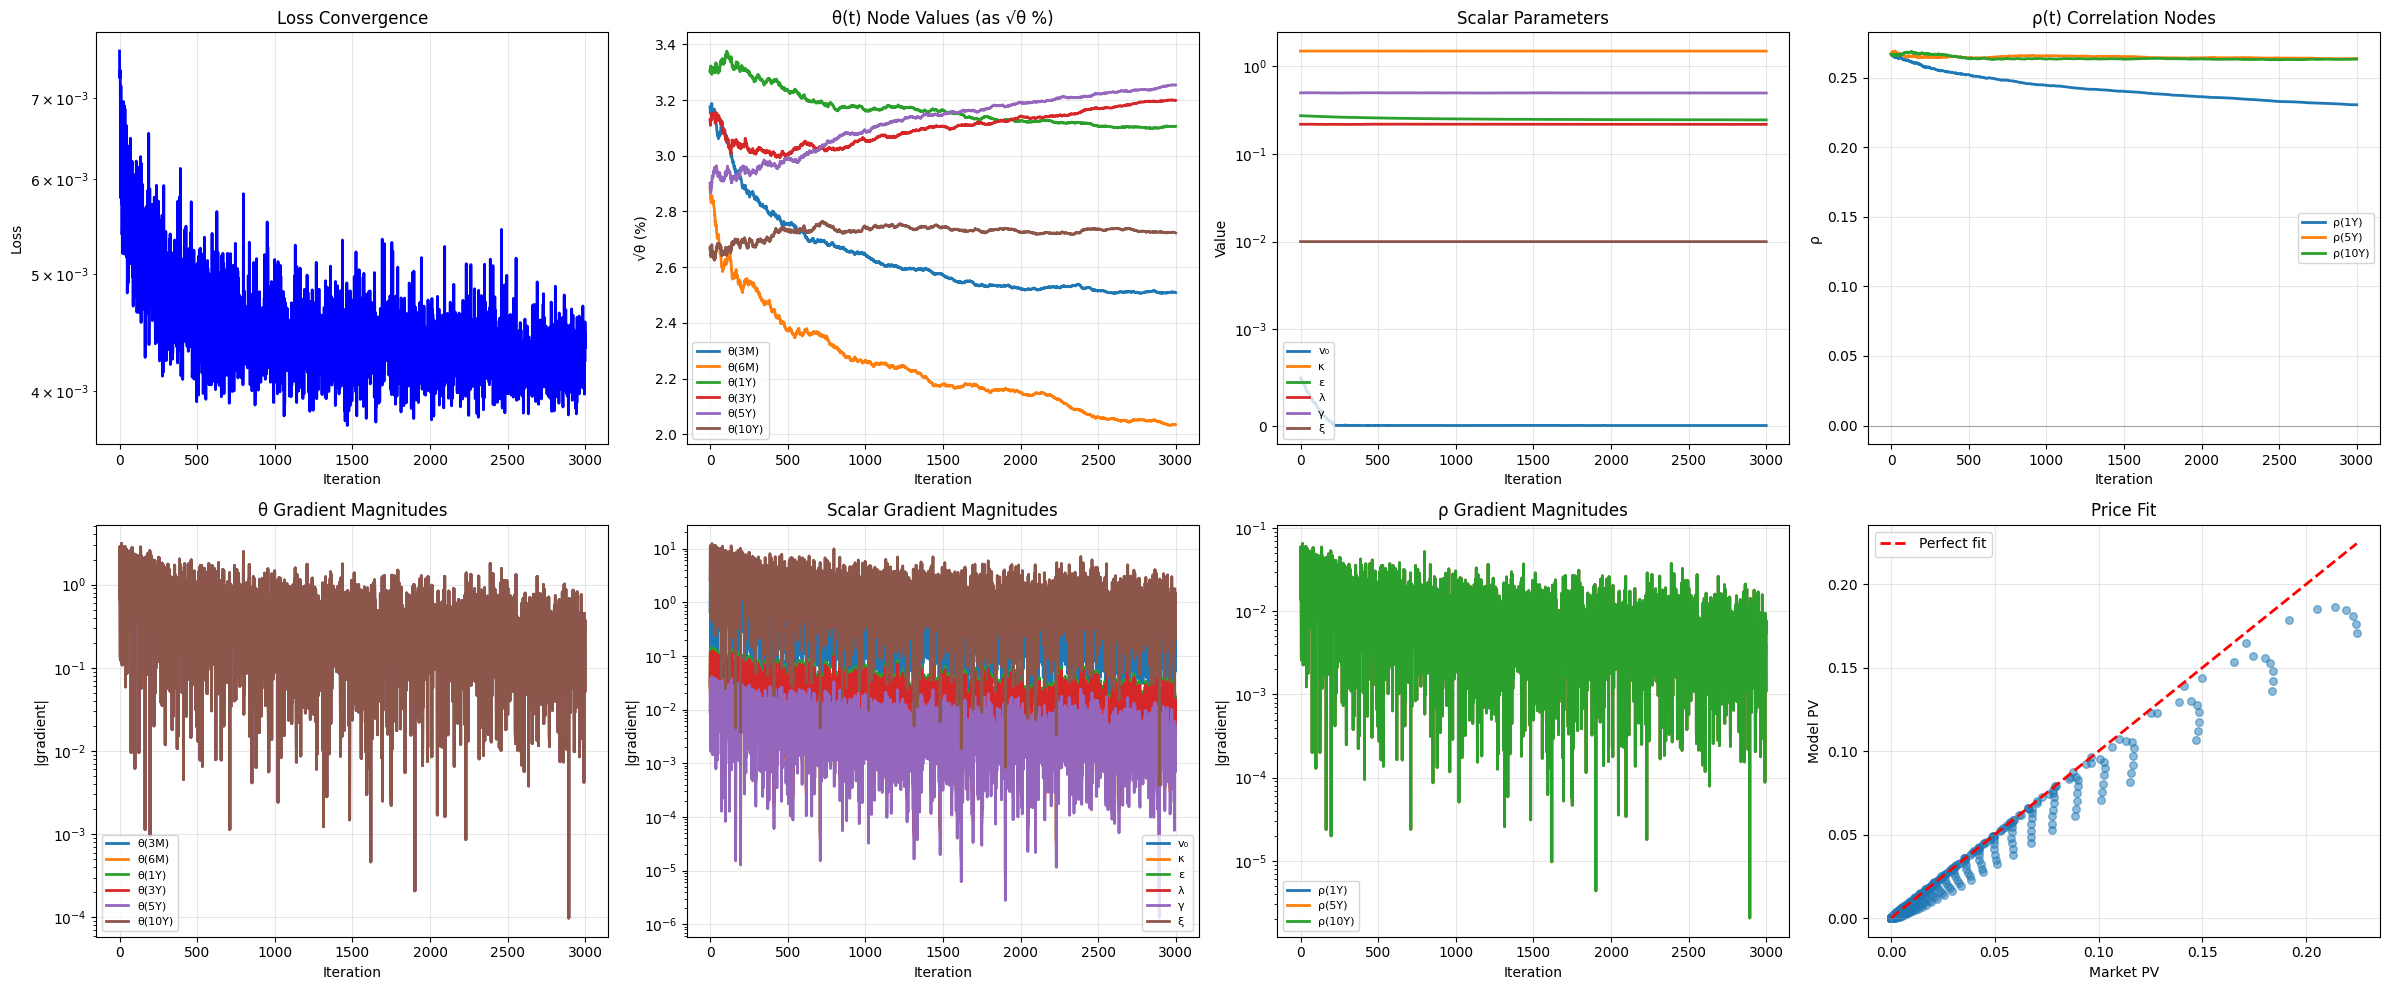

Price RMSE: 8.8610e-03

History stored: 3000 iterations Ã— 22 fields per iteration

Final iteration 2999 snapshot:
  Î¸(3M): 0.000629  grad=-2.6522e-01
  Î¸(6M): 0.000414  grad=2.6522e-01
  Î¸(1Y): 0.000964  grad=2.6522e-01
  Î¸(3Y): 0.001023  grad=2.6522e-01
  Î¸(5Y): 0.001059  grad=-2.6522e-01
  Î¸(10Y): 0.000741  grad=2.6522e-01
  vâ‚€: 0.000010  grad=2.6396e-01
  Îº: 1.498651  grad=8.7964e-03
  Îµ: 0.245468  grad=1.2419e-02
  Î»: 0.218229  grad=1.0662e-02
  Î³: 0.497932  grad=3.5303e-03
  Î¾: 0.009995  grad=-1.0566e+00
  Ï(1Y): 0.230620  grad=-5.5556e-03
  Ï(5Y): 0.263866  grad=5.5556e-03
  Ï(10Y): 0.263432  grad=5.5556e-03


In [17]:
if not RETRAIN:
    print("Skipped â€” convergence plots only available after RETRAIN=True run.")
else:
    hist_df = pd.DataFrame(history)
    theta_names = ['Î¸(3M)', 'Î¸(6M)', 'Î¸(1Y)', 'Î¸(3Y)', 'Î¸(5Y)', 'Î¸(10Y)']
    scalar_names = ['v0', 'kappa', 'epsilon', 'lam', 'gamma', 'xi']
    scalar_display = ['vâ‚€', 'Îº', 'Îµ', 'Î»', 'Î³', 'Î¾']
    rho_names = ['rho_1y', 'rho_5y', 'rho_10y']
    rho_display = ['Ï(1Y)', 'Ï(5Y)', 'Ï(10Y)']
    grad_scalar = ['grad_v0', 'grad_kappa', 'grad_eps', 'grad_lam', 'grad_gamma', 'grad_xi']
    grad_rho = ['grad_rho1', 'grad_rho5', 'grad_rho10']

    fig, axes = plt.subplots(2, 4, figsize=(24, 10))

    # 1) Loss convergence
    axes[0, 0].plot(hist_df['iter'], hist_df['loss'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Iteration'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss Convergence'); axes[0, 0].set_yscale('log'); axes[0, 0].grid(alpha=0.3)

    # 2) Theta node values (as âˆšÎ¸ %)
    for i, name in enumerate(theta_names):
        vals = [np.sqrt(h['theta'][i]) * 100 for h in history]
        axes[0, 1].plot(hist_df['iter'], vals, '-', linewidth=2, label=name)
    axes[0, 1].set_xlabel('Iteration'); axes[0, 1].set_ylabel('âˆšÎ¸ (%)')
    axes[0, 1].set_title('Î¸(t) Node Values (as âˆšÎ¸ %)'); axes[0, 1].legend(fontsize=8); axes[0, 1].grid(alpha=0.3)

    # 3) Scalar parameters (excl. rho)
    for name, disp in zip(scalar_names, scalar_display):
        axes[0, 2].plot(hist_df['iter'], hist_df[name], '-', linewidth=2, label=disp)
    axes[0, 2].set_xlabel('Iteration'); axes[0, 2].set_ylabel('Value')
    axes[0, 2].set_title('Scalar Parameters'); axes[0, 2].legend(fontsize=8)
    axes[0, 2].grid(alpha=0.3); axes[0, 2].set_yscale('symlog', linthresh=1e-3)

    # 4) Rho(t) nodes over iterations
    for name, disp in zip(rho_names, rho_display):
        axes[0, 3].plot(hist_df['iter'], hist_df[name], '-', linewidth=2, label=disp)
    axes[0, 3].set_xlabel('Iteration'); axes[0, 3].set_ylabel('Ï')
    axes[0, 3].set_title('Ï(t) Correlation Nodes'); axes[0, 3].legend(fontsize=8)
    axes[0, 3].grid(alpha=0.3); axes[0, 3].axhline(0, color='grey', lw=0.5)

    # 5) Theta gradient magnitudes
    for i, name in enumerate(theta_names):
        vals = [abs(h['grad_theta'][i]) for h in history]
        axes[1, 0].plot(hist_df['iter'], vals, '-', linewidth=2, label=name)
    axes[1, 0].set_xlabel('Iteration'); axes[1, 0].set_ylabel('|gradient|')
    axes[1, 0].set_title('Î¸ Gradient Magnitudes'); axes[1, 0].legend(fontsize=8)
    axes[1, 0].set_yscale('log'); axes[1, 0].grid(alpha=0.3)

    # 6) Scalar gradient magnitudes
    for gn, disp in zip(grad_scalar, scalar_display):
        axes[1, 1].plot(hist_df['iter'], hist_df[gn].abs(), '-', linewidth=2, label=disp)
    axes[1, 1].set_xlabel('Iteration'); axes[1, 1].set_ylabel('|gradient|')
    axes[1, 1].set_title('Scalar Gradient Magnitudes'); axes[1, 1].legend(fontsize=8)
    axes[1, 1].set_yscale('log'); axes[1, 1].grid(alpha=0.3)

    # 7) Rho gradient magnitudes
    for gn, disp in zip(grad_rho, rho_display):
        axes[1, 2].plot(hist_df['iter'], hist_df[gn].abs(), '-', linewidth=2, label=disp)
    axes[1, 2].set_xlabel('Iteration'); axes[1, 2].set_ylabel('|gradient|')
    axes[1, 2].set_title('Ï Gradient Magnitudes'); axes[1, 2].legend(fontsize=8)
    axes[1, 2].set_yscale('log'); axes[1, 2].grid(alpha=0.3)

    # 8) Price scatter
    best_theta = best_params['theta']
    theta_vec_final = theta_to_vec(best_theta, theta_nodes, timeline)
    bp = best_params
    rho_nodes_v = torch.tensor([bp['rho_1y'], bp['rho_5y'], bp['rho_10y']],
                                dtype=torch.float32, device=device)
    rho_vec_final = rho_to_vec(rho_nodes_v, rho_nodes_t, timeline)
    key_paths_final, ois_paths_final, _ = fast_simulate(
        1000, timeline, theta_vec_final,
        bp['epsilon'], bp['v0'], bp['kappa'],
        bp['lam'], bp['gamma'], bp['xi'],
        f_key_vec, f_ois_vec, device, seed=12345,
        rho_vx=rho_vec_final
    )
    model_pvs, _, _ = batch_price_caplets(key_paths_final, ois_paths_final, timeline, idx_fixes, idx_pays, strikes, tau, device)
    market_pvs = market_pvs_cached
    axes[1, 3].scatter(market_pvs.cpu().numpy(), model_pvs.cpu().numpy(), alpha=0.5, s=30)
    max_pv = max(market_pvs.max().item(), model_pvs.max().item())
    axes[1, 3].plot([0, max_pv], [0, max_pv], 'r--', linewidth=2, label='Perfect fit')
    axes[1, 3].set_xlabel('Market PV'); axes[1, 3].set_ylabel('Model PV')
    axes[1, 3].set_title('Price Fit'); axes[1, 3].legend(); axes[1, 3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary
    pv_rmse = torch.sqrt(torch.mean((model_pvs - market_pvs)**2)).item()
    print(f'Price RMSE: {pv_rmse:.4e}')
    print(f'\nHistory stored: {len(history)} iterations Ã— {len(history[0])} fields per iteration')

    # Print final iteration snapshot
    last = history[-1]
    print(f'\nFinal iteration {last["iter"]} snapshot:')
    for i, name in enumerate(theta_names):
        print(f'  {name}: {last["theta"][i]:.6f}  grad={last["grad_theta"][i]:.4e}')
    for name, disp, gn in zip(scalar_names, scalar_display, grad_scalar):
        print(f'  {disp}: {last[name]:.6f}  grad={last[gn]:.4e}')
    for name, disp, gn in zip(rho_names, rho_display, grad_rho):
        print(f'  {disp}: {last[name]:.6f}  grad={last[gn]:.4e}')

Using freshly trained best_params (RETRAIN=True).

FAST VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid vol inversions: 477 (96.4%)
Failed inversions:    18
Sub-intrinsic (conv): 0 (MC price < det. intrinsic â†’ NaN)
Vol RMSE:             5.920%
Model vol range:      1.65% - 51.16%
Market vol range:     0.97% - 10.58%


Surface Coverage: 477/495 points (96.4%)
Missing 18 points due to inversion failures


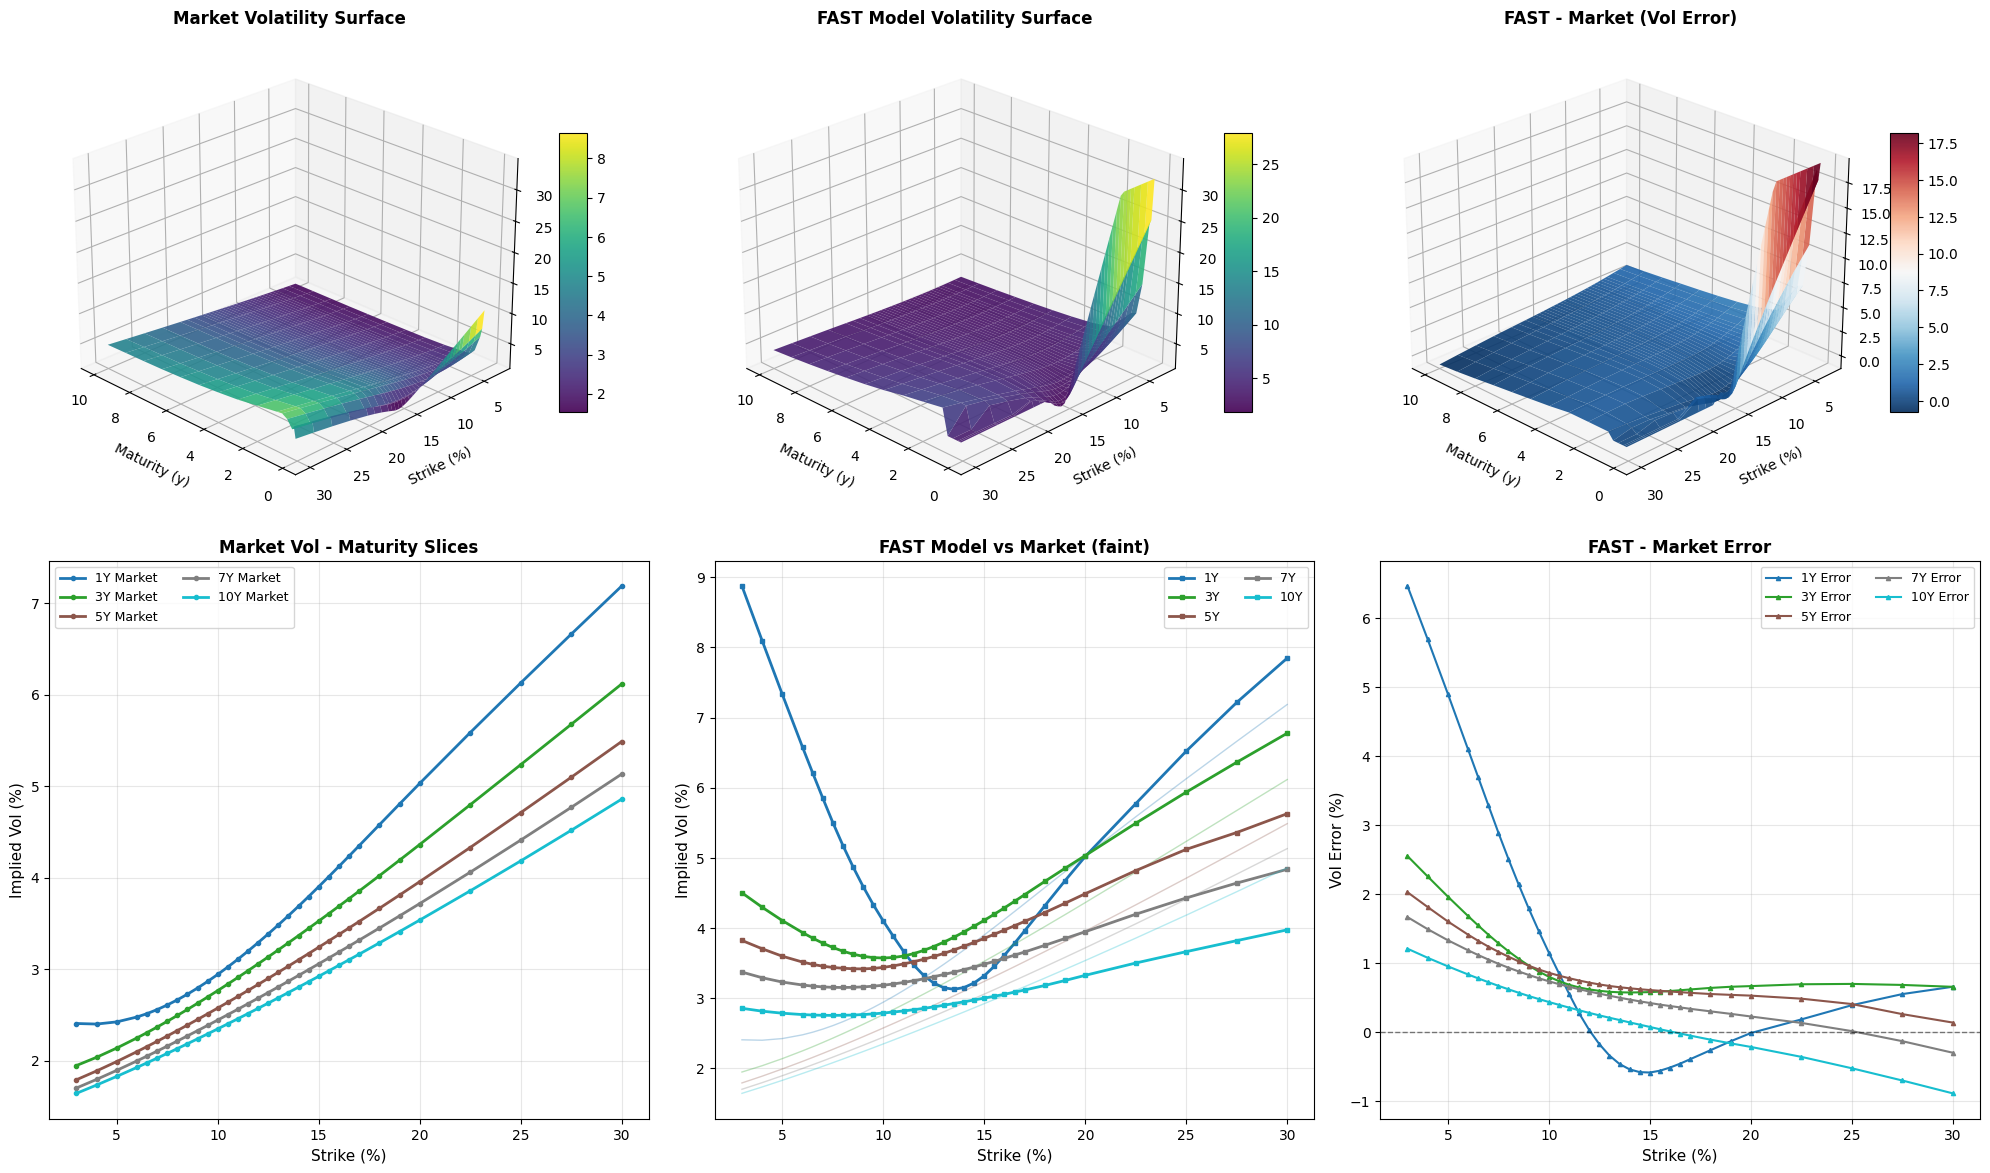


Calibrated vol surface RMSE: 0.0592
  Ï(t)=[+0.240, +0.265, +0.264]


In [18]:
# Force reimport vol surface utilities
import importlib
import affine_calibration.caplet_vol_surface as cvs
importlib.reload(cvs)
from affine_calibration.caplet_vol_surface import (generate_caplet_vol_surface, plot_caplet_vol_surface, 
                                    plot_caplet_price_heatmaps, print_model_vs_market_table)

# ============================================
# LOAD PARAMS FROM CHECKPOINT
# ============================================
# Loads saved weights unless RETRAIN was True and best_params already set by training.
import pickle
weights_dir = Path('calibration_weights')
weights_dir.mkdir(exist_ok=True)
checkpoint_path = weights_dir / 'fast_calibration_v8.pkl'

_need_load = (not RETRAIN) or ('best_params' not in dir()) or (best_params is None)
if _need_load:
    print(f"Loading calibrated params from {checkpoint_path}")
    with open(checkpoint_path, 'rb') as f:
        checkpoint = pickle.load(f)

    # --- Validate checkpoint is from v8 training ---
    _missing_rho = not all(k in checkpoint for k in ('rho_1y', 'rho_5y', 'rho_10y'))
    _kappa_oob = not (kappa_min <= checkpoint['kappa'] <= kappa_max)
    _eps_oob = not (eps_min <= checkpoint['epsilon'] <= eps_max)
    _xi_oob = not (xi_min <= checkpoint['xi'] <= xi_max)
    _stale = _missing_rho or _kappa_oob or _eps_oob or _xi_oob

    if _stale:
        print("\n" + "!" * 80)
        print("WARNING: Checkpoint appears STALE (from pre-v8 training)!")
        if _missing_rho:
            print(f"  - Missing rho_1y/rho_5y/rho_10y (all rhos will default to 0.0!)")
        if _kappa_oob:
            print(f"  - kappa={checkpoint['kappa']:.4f} outside v8 bounds [{kappa_min}, {kappa_max}]")
        if _eps_oob:
            print(f"  - epsilon={checkpoint['epsilon']:.4f} outside v8 bounds [{eps_min}, {eps_max}]")
        if _xi_oob:
            print(f"  - xi={checkpoint['xi']:.6f} outside v8 bounds [{xi_min}, {xi_max}]")
        print(f"  - Checkpoint iterations: {checkpoint.get('iteration', '?')} (v8 uses {1500})")
        print("  => Set RETRAIN=True in the training cell, run it, then run the Save cell!")
        print("!" * 80 + "\n")

    best_params = {
        'theta': checkpoint['theta_values'].to(device),
        'v0': checkpoint['v0'],
        'kappa': checkpoint['kappa'],
        'epsilon': checkpoint['epsilon'],
        'lam': checkpoint['lam'],
        'gamma': checkpoint['gamma'],
        'xi': checkpoint['xi'],
        'rho_1y': checkpoint.get('rho_1y', checkpoint.get('rho_vx', 0.0)),
        'rho_5y': checkpoint.get('rho_5y', checkpoint.get('rho_vx', 0.0)),
        'rho_10y': checkpoint.get('rho_10y', checkpoint.get('rho_vx', 0.0)),
    }
    theta_nodes = checkpoint['theta_nodes'].to(device)
    print(f"  Loaded: theta={best_params['theta'].cpu().numpy()}")
    print(f"  v0={best_params['v0']:.6f}, kappa={best_params['kappa']:.4f}, eps={best_params['epsilon']:.4f}")
    print(f"  rho=[{_val(best_params['rho_1y']):+.3f}, {_val(best_params['rho_5y']):+.3f}, {_val(best_params['rho_10y']):+.3f}]")
else:
    print(f"Using freshly trained best_params (RETRAIN=True).")

# ============================================
# GENERATE VOL SURFACE FROM CALIBRATED PARAMS
# ============================================
bp = best_params
theta_vec_final = theta_to_vec(bp['theta'], theta_nodes, timeline)
rho_nodes_v = torch.tensor([_val(bp['rho_1y']), _val(bp['rho_5y']), _val(bp['rho_10y'])],
                           dtype=torch.float32, device=device)
rho_vec_final = rho_to_vec(rho_nodes_v, rho_nodes_t, timeline)

key_paths_final, ois_paths_final, _ = fast_simulate(
    20000, timeline, theta_vec_final,
    _val(bp['epsilon']), _val(bp['v0']),
    _val(bp['kappa']), _val(bp['lam']),
    _val(bp['gamma']), _val(bp['xi']),
    f_key_vec, f_ois_vec, device, seed=12345,
    rho_vx=rho_vec_final
)
model_pvs_final, F_model_final, P_model_final = batch_price_caplets(
    key_paths_final, ois_paths_final, timeline, idx_fixes, idx_pays, strikes, tau, device
)

vol_key_rate_final = vol_key_rate.copy()
vol_key_rate_final['pv_model_key'] = model_pvs_final.cpu().numpy()
vol_results, vol_rmse = generate_caplet_vol_surface(
    vol_key_rate_final, fwd_key_rate, fwd_ois=fwd_ois, version_name="Fast",
    F_model=F_model_final.cpu().numpy(), P_model=P_model_final.cpu().numpy()
)
plot_caplet_vol_surface(vol_results, version_name="Fast")

full_rmse = vol_rmse
print(f"\nCalibrated vol surface RMSE: {vol_rmse:.4f}")
print(f"  Ï(t)=[{_val(bp['rho_1y']):+.3f}, {_val(bp['rho_5y']):+.3f}, {_val(bp['rho_10y']):+.3f}]")

In [ ]:
# Save checkpoint with ALL calibrated parameters
import pickle

weights_dir = Path('calibration_weights')
weights_dir.mkdir(exist_ok=True)

checkpoint = {
    'theta_nodes': theta_nodes.cpu(),
    'theta_values': best_params['theta'].cpu(),
    'v0': _val(best_params['v0']),
    'kappa': _val(best_params['kappa']),
    'epsilon': _val(best_params['epsilon']),
    'lam': _val(best_params['lam']),
    'gamma': _val(best_params['gamma']),
    'xi': _val(best_params['xi']),
    'rho_1y': _val(best_params.get('rho_1y', 0.0)),
    'rho_5y': _val(best_params.get('rho_5y', 0.0)),
    'rho_10y': _val(best_params.get('rho_10y', 0.0)),
    'loss': best_loss,
    'history': history,
    'iteration': len(history)
}

save_path = weights_dir / 'fast_calibration_v8.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Saved checkpoint to {save_path}: loss={best_loss:.4e}, {len(history)} iterations")
print(f"  theta = {best_params['theta'].cpu().numpy()}")
print(f"  v0={_val(best_params['v0']):.4f}, Îº={_val(best_params['kappa']):.2f}, Îµ={_val(best_params['epsilon']):.3f}")
print(f"  Î»={_val(best_params['lam']):.3f}, Î³={_val(best_params['gamma']):.3f}, Î¾={_val(best_params['xi']):.4f}")
print(f"  Ï(t)=[{_val(best_params.get('rho_1y', 0.0)):+.3f}, {_val(best_params.get('rho_5y', 0.0)):+.3f}, {_val(best_params.get('rho_10y', 0.0)):+.3f}]")

Saved checkpoint: loss=6.8721e-02, 300 iterations
  theta = [0.00076569 0.00056108 0.00013267 0.00233011 0.0014996  0.00238352]
  v0=0.0003, Îº=1.68, Îµ=0.095
  Î»=0.290, Î³=0.010, Î¾=0.0236
